In [1]:
import joblib
df = joblib.load('processed_data.joblib')

In [2]:
X_train = df["X_train"]
y_train = df["y_train"]
X_test = df["X_test"]
y_test = df["y_test"]


In [4]:
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score

f1_train_scores = []
f1_test_scores = []
lr_val = []

learning_rates = np.arange(0.001,1.001,0.001)
for lr in learning_rates :
    model = SGDClassifier(loss="log_loss",
        learning_rate="constant",
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        random_state=42)
    model.fit(X_train,y_train)
    f1_train_scores.append(f1_score(y_train,model.predict(X_train)))
    f1_test_scores.append(f1_score(y_test,model.predict(X_test)))
    lr_val.append(lr)



In [7]:
import pandas as pd
results = pd.DataFrame({
    "Learning_Rate": learning_rates,
    "Training_F1": f1_train_scores,
    "Testing_F1": f1_test_scores
})

print(results.head())

   Learning_Rate  Training_F1  Testing_F1
0          0.001     0.999818    0.998722
1          0.002     0.999818    0.999148
2          0.003     0.999818    0.999148
3          0.004     0.999818    0.999148
4          0.005     0.999818    0.999148


In [9]:
best_index = results["Testing_F1"].idxmax()

best_lr = results.loc[best_index, "Learning_Rate"]
best_train_f1 = results.loc[best_index, "Training_F1"]
best_test_f1 = results.loc[best_index, "Testing_F1"]

print("Best Learning Rate:", best_lr)
print("Training F1:", best_train_f1)
print("Testing F1:", best_test_f1)

Best Learning Rate: 0.019000000000000003
Training F1: 1.0
Testing F1: 1.0


In [10]:
results["F1_Gap"] = abs(
    results["Training_F1"] - results["Testing_F1"]
)

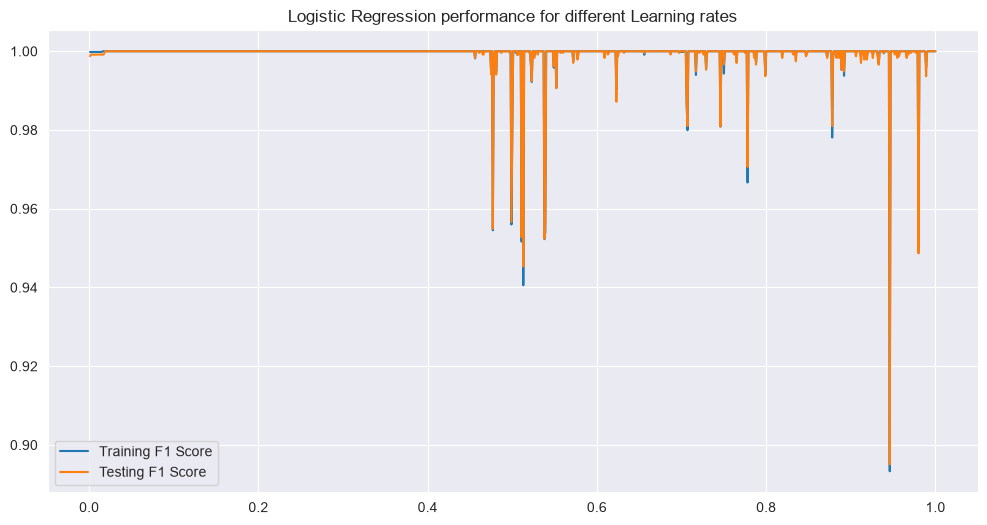

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))

sns.lineplot(x=lr_val, y=f1_train_scores, label="Training F1 Score")
sns.lineplot(x=lr_val, y=f1_test_scores, label="Testing F1 Score")

plt.xlabel = "Learning rate values"
plt.ylabel = "f1_score"
plt.title("Logistic Regression performance for different Learning rates")
plt.legend()
plt.grid(True)
plt.show()
